In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print("Path to dataset files:", path)

100%|██████████| 493M/493M [00:24<00:00, 20.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7


In [3]:
import os
print(os.listdir(path))

['train.ft.txt.bz2', 'test.ft.txt.bz2']


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,GRU,Bidirectional,LSTM,Dense,Dropout,LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import bz2
import csv
import re
import os


In [5]:
train_file = os.path.join(path,"train.ft.txt.bz2")
test_file = os.path.join(path, "test.ft.txt.bz2")
print(train_file)
print(test_file)

/root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7/train.ft.txt.bz2
/root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7/test.ft.txt.bz2


In [6]:
#Loading Subset of the Data
with bz2.BZ2File("/root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7/train.ft.txt.bz2") as f:
  training_data=[f.readline().decode('utf-8').strip() for _ in range (12000)]

with bz2.BZ2File("/root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7/test.ft.txt.bz2") as f:
  test_data=[f.readline().decode('utf-8').strip() for _ in range (3000)]


In [7]:
print(training_data[0])
print(test_data[0])

print("Training samples:", len(training_data))
print("Test samples:", len(test_data))

__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
__label__2 Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"
Training samples:

Preparing Dataset

In [8]:
def extract_label_and_text(data):
    labels = []
    texts = []

    for review in data:
        label, text = review.split(" ", 1)

        # __label__1 → 0 (Negative)
        # __label__2 → 1 (Positive)
        label = int(label.replace("__label__", "")) - 1

        labels.append(label)
        texts.append(text)

    return texts, labels

In [9]:
train_text, train_labels = extract_label_and_text(training_data)
test_text, test_labels = extract_label_and_text(test_data)

In [10]:
print(test_labels[:4])
print(test_text[:4])

[1, 1, 0, 1]
['Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I\'m in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life\'s hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"', "One of the best game music soundtracks - for a game I didn't really play: Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of thos

Preprocessing and Cleaning Text

In [11]:
import nltk
from nltk.corpus import stopwords #removes the useless words
from nltk.stem import PorterStemmer  #converts the words to it og tense form
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
def clean_text(text):
  ps=PorterStemmer()
  stop_words=set(stopwords.words("english"))

  #lowercasing
  text=text.lower()
  text = re.sub(r"[^a-z\s]","",text) #removes special characters
  words= text.split()
  words=[ps.stem(word) for word in words if word not in stop_words]
  #cleaned_words = []
  #   for word in words:
  #       if word not in stop_words:
  #           stemmed_word = ps.stem(word)
  #           cleaned_words.append(stemmed_word)

  return " ".join(words)

training_texts=[clean_text(text) for text in train_text]
test_texts=[clean_text(text) for text in test_text]


In [13]:
max_length = 0
for text in training_texts:
    length = len(text.split())
    if length > max_length:
        max_length = length
print("Maximum training text length:", max_length)

Maximum training text length: 139


# ***Tokenization*** and ***Padding***

In [14]:
max_words=10000
max_sequence_length=140
tokenizer= Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(training_texts)

x_train=tokenizer.texts_to_sequences(training_texts)
x_test=tokenizer.texts_to_sequences(test_texts)

x_train=pad_sequences(x_train,maxlen=max_sequence_length,padding='post')
x_test=pad_sequences(x_test,maxlen=max_sequence_length,padding='post')

In [15]:
x_train[:5]

array([[  19,   95,  195,  194,  978,  319,   21,   10, 1221,   19,   59,
         403, 9559,   73,   56,   66,   73, 5050, 1402,   73,   49,   66,
          27,   56,   48,  176, 2378, 2529,   69, 9560,  806, 3657,  954,
         869, 3104,   10,  439,  120,  261,  152,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0],
       [  27,  738,   49,  209,   36,    3,   85,   44,

In [16]:
#Change 2D array to 1D Array
import numpy as np
x_train=np.array(x_train)
x_test=np.array(x_test)
y_train=np.array(train_labels)
y_test=np.array(test_labels)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 140)
(3000, 140)
(12000,)
(3000,)


Training ***RNN***

In [25]:
import tensorflow as tf
tf.keras.utils.set_random_seed(42)

In [34]:
# model=Sequential([
#     Embedding(input_dim=max_words,output_dim=300,input_length=max_sequence_length),
#     SimpleRNN(128,return_sequences=True,dropout=0.3),
#     LayerNormalization(),
#     SimpleRNN(128,dropout=0.3),
#     LayerNormalization(),
#     Dropout(0.3),

#     Dense(64,activation='relu'),
#     Dropout(0.2),
#     Dense(1,activation='sigmoid') #Binary Classification
# ])

# model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

# history=model.fit(x_train,y_train,epochs=50,batch_size=128,
#                   validation_data=(x_test,y_test),
#                   callbacks=[early_stopping])

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=300
    ),

    SimpleRNN(128),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=early_stopping)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.5089 - loss: 0.6970 - val_accuracy: 0.5883 - val_loss: 0.6771
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5002 - loss: 0.7010 - val_accuracy: 0.4620 - val_loss: 0.7100
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5123 - loss: 0.7057 - val_accuracy: 0.5330 - val_loss: 0.6894
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6241 - loss: 0.6652 - val_accuracy: 0.6410 - val_loss: 0.6517
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6046 - loss: 0.6732 - val_accuracy: 0.6027 - val_loss: 0.6687
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5824 - loss: 0.6774 - val_accuracy: 0.6150 - val_loss: 0.6630
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6337 - loss: 0.6518 - val_accuracy: 0.6267 - val_loss: 0.6718
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6783 - loss: 0.6177 - val_accuracy: 0.6613 - v

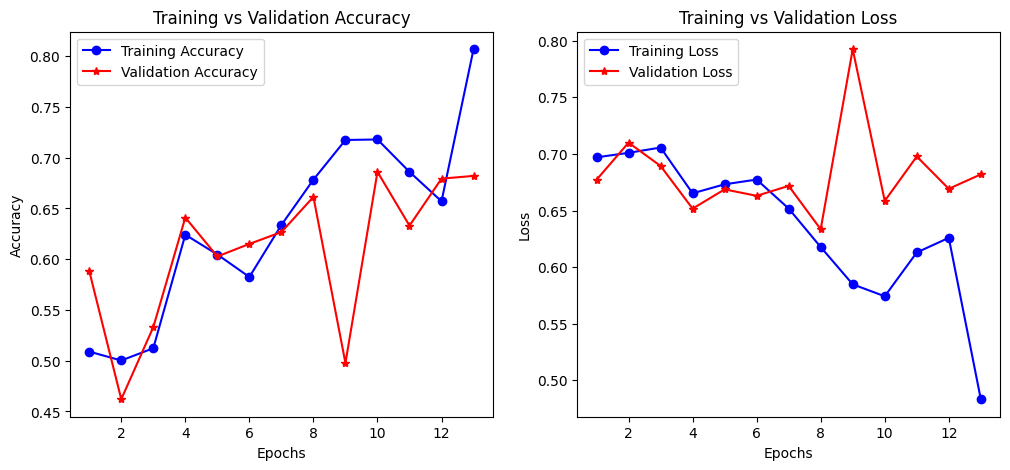

In [35]:
# Model Evaluation
epochs=range(1,len(history.history['accuracy'])+1)
train_acc_rnn=history.history['accuracy']
val_acc_rnn=history.history['val_accuracy']
train_loss_rnn=history.history['loss']
val_loss_rnn=history.history['val_loss']

#Plotting the graphs
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,train_acc_rnn,'bo-',label='Training Accuracy')
plt.plot(epochs,val_acc_rnn,'r*-',label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs,train_loss_rnn,'bo-',label='Training Loss')
plt.plot(epochs,val_loss_rnn,'r*-',label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

In [36]:
y_pred_rnn=model.predict(x_test)
y_pred_rnn=(y_pred_rnn>0.5).astype(int).flatten()

cm_rnn=confusion_matrix(y_test,y_pred_rnn)
print("Confusion_Matrix:\n",cm_rnn)

report_rnn=classification_report(y_test,y_pred_rnn)
print('\nClassification Report SimpleRNN:\n',report_rnn)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Confusion_Matrix:
 [[ 909  528]
 [ 488 1075]]

Classification Report SimpleRNN:
               precision    recall  f1-score   support

           0       0.65      0.63      0.64      1437
           1       0.67      0.69      0.68      1563

    accuracy                           0.66      3000
   macro avg       0.66      0.66      0.66      3000
weighted avg       0.66      0.66      0.66      3000



***LSTM*** ***Model***

In [38]:
tf.keras.utils.set_random_seed(42)

lstm_model=Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=max_sequence_length),
    Bidirectional(LSTM(128,return_sequences=True,recurrent_dropout=0.2)),
    LayerNormalization(),
    Bidirectional(LSTM(128,dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),

    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid') #Binary Classification
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=lstm_model.fit(x_train,y_train,epochs=50,batch_size=128,
                  validation_data=(x_test,y_test),
                  callbacks=early_stopping)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 90s 875ms/step - accuracy: 0.7479 - loss: 0.5085 - val_accuracy: 0.8240 - val_loss: 0.3886
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 90s 958ms/step - accuracy: 0.8978 - loss: 0.2539 - val_accuracy: 0.8430 - val_loss: 0.4273
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 871ms/step - accuracy: 0.9352 - loss: 0.1709 - val_accuracy: 0.8333 - val_loss: 0.4685
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 948ms/step - accuracy: 0.9527 - loss: 0.1245 - val_accuracy: 0.8203 - val_loss: 0.5891
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 873ms/step - accuracy: 0.9680 - loss: 0.0943 - val_accuracy: 0.8203 - val_loss: 0.5882
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9781 - loss: 0.0638 - val_accuracy: 0.8093 - val_loss: 0.8151


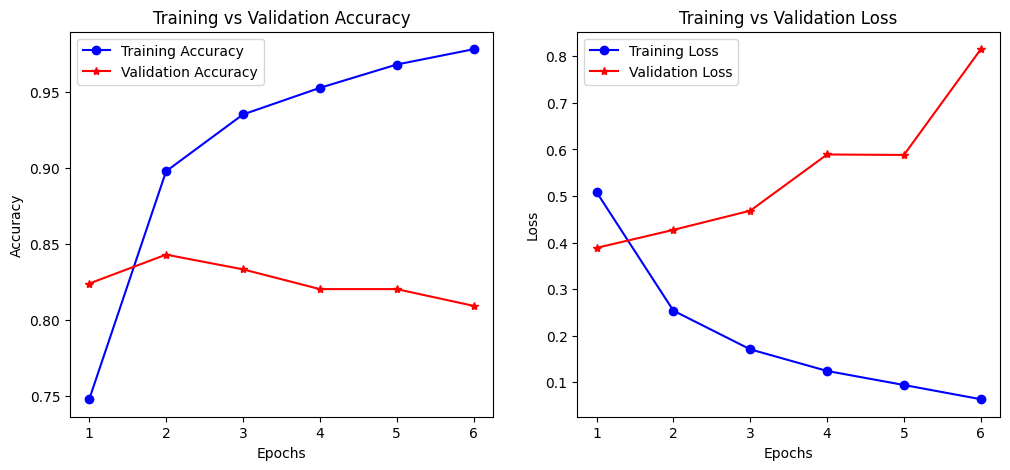

In [39]:
# Model LSTM Evaluation
epochs=range(1,len(history.history['accuracy'])+1)
train_acc_lstm=history.history['accuracy']
val_acc_lstm=history.history['val_accuracy']
train_loss_lstm=history.history['loss']
val_loss_lstm=history.history['val_loss']

#Plotting the graphs
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,train_acc_lstm,'bo-',label='Training Accuracy')
plt.plot(epochs,val_acc_lstm,'r*-',label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs,train_loss_lstm,'bo-',label='Training Loss')
plt.plot(epochs,val_loss_lstm,'r*-',label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

In [40]:
y_pred_lstm=lstm_model.predict(x_test)
y_pred_lstm=(y_pred_lstm>0.5).astype(int).flatten()

cm_lstm=confusion_matrix(y_test,y_pred_lstm)
print("Confusion_Matrix:\n",cm_lstm)

report_lstm=classification_report(y_test,y_pred_lstm)
print('\nClassification Report SimpleRNN:\n',report_lstm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step
Confusion_Matrix:
 [[1194  243]
 [ 285 1278]]

Classification Report SimpleRNN:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82      1437
           1       0.84      0.82      0.83      1563

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



***GRU***

In [42]:
gru_model=Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=max_sequence_length),
    GRU(128,return_sequences=True,dropout=0.3,recurrent_dropout=0.2),
    LayerNormalization(),
    GRU(128,dropout=0.3,recurrent_dropout=0.2),
    LayerNormalization(),
    Dropout(0.3),

    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid') #Binary Classification
])

gru_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=gru_model.fit(x_train,y_train,epochs=50,batch_size=128,
                  validation_data=(x_test,y_test),
                  callbacks=[early_stopping])

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5027 - loss: 0.7286 - val_accuracy: 0.4790 - val_loss: 0.6919
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 91s 966ms/step - accuracy: 0.6287 - loss: 0.6289 - val_accuracy: 0.7917 - val_loss: 0.4608
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 90s 958ms/step - accuracy: 0.8474 - loss: 0.3797 - val_accuracy: 0.8457 - val_loss: 0.3690
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 948ms/step - accuracy: 0.9127 - loss: 0.2391 - val_accuracy: 0.8293 - val_loss: 0.4862
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 952ms/step - accuracy: 0.9434 - loss: 0.1665 - val_accuracy: 0.8300 - val_loss: 0.5548
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 141s 947ms/step - accuracy: 0.9594 - loss: 0.1228 - val_accuracy: 0.8230 - val_loss: 0.5804
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 949ms/step - accuracy: 0.9663 - loss: 0.1059 - val_accuracy: 0.8110 - val_loss: 0.6031
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 142s 952ms/step - accuracy: 0.9740 - loss: 0.0793 - val_accu

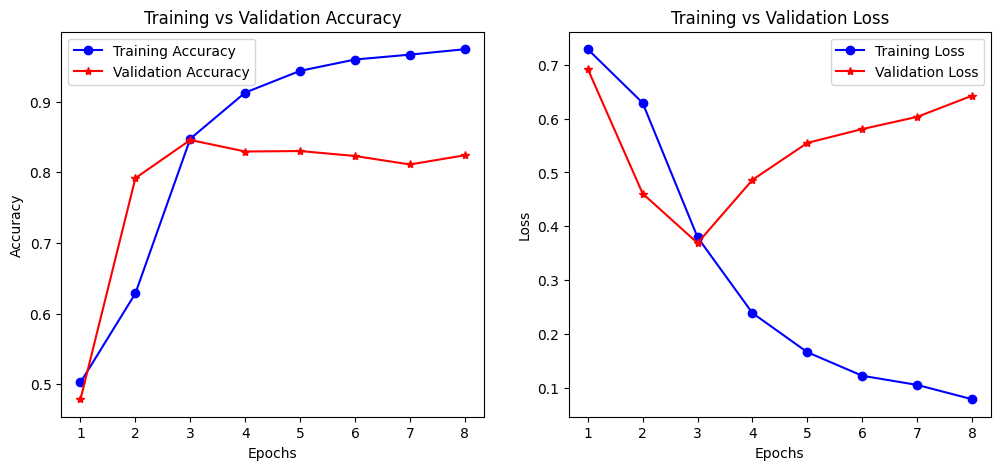

In [43]:
# Model GRU Evaluation
epochs=range(1,len(history.history['accuracy'])+1)
train_acc_gru=history.history['accuracy']
val_acc_gru=history.history['val_accuracy']
train_loss_gru=history.history['loss']
val_loss_gru=history.history['val_loss']

#Plotting the graphs
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,train_acc_gru,'bo-',label='Training Accuracy')
plt.plot(epochs,val_acc_gru,'r*-',label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs,train_loss_gru,'bo-',label='Training Loss')
plt.plot(epochs,val_loss_gru,'r*-',label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

In [45]:
y_pred_gru=gru_model.predict(x_test)
y_pred_gru=(y_pred_gru>0.5).astype(int).flatten()

cm_gru=confusion_matrix(y_test,y_pred_gru)
print("Confusion_Matrix:\n",cm_gru)

report_gru=classification_report(y_test,y_pred_gru)
print('\nClassification Report GRU:\n',report_gru)

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step
Confusion_Matrix:
 [[1172  265]
 [ 198 1365]]

Classification Report GRU:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1437
           1       0.84      0.87      0.85      1563

    accuracy                           0.85      3000
   macro avg       0.85      0.84      0.85      3000
weighted avg       0.85      0.85      0.85      3000



In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt

# Store all models
models = {
    "SimpleRNN": model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = []

for model_name, model in models.items():

    # Predict probabilities
    y_pred_prob = model.predict(x_test)

    # Convert probabilities to binary predictions
    y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Print individual results
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

# Create DataFrame
results_df = pd.DataFrame(results)

print("\nFinal Model Comparison:")
print(results_df)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

SimpleRNN Results

Confusion Matrix:
[[ 909  528]
 [ 488 1075]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      1437
           1       0.67      0.69      0.68      1563

    accuracy                           0.66      3000
   macro avg       0.66      0.66      0.66      3000
weighted avg       0.66      0.66      0.66      3000

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step

LSTM Results

Confusion Matrix:
[[1194  243]
 [ 285 1278]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1437
           1       0.84      0.82      0.83      1563

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step

GRU Results

Confusion Matrix:
[[1172  265]
 [ 19

Detection System

In [48]:
#Preprocess Data
def predict(text,model,tokenizer,max_sequence_length=140):
  text=clean_text(text)
  sequence=tokenizer.texts_to_sequences([text])
  padded_sequence=pad_sequences(sequence,maxlen=max_sequence_length,padding='post')

  #Predict Sentiment
  prediction=model.predict(padded_sequence)[0][0]

  #check if review positive or negative
  sentiment="Positive" if prediction>0.5 else "Negative"

  return sentiment,float(prediction)


test_sentences=["I love this product! Its amazing ","This is the worst service i have ever brought","The Movie was okay, nor great but not terrible either"]

for sentence in test_sentences:
  sentiment, confidence= predict(sentence,gru_model,tokenizer)
  print(f"Text:{sentence}\nPredicted Sentiment:{sentiment}\nConfidence:{confidence*100:.4f}")





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
Text:I love this product! Its amazing 
Predicted Sentiment:Positive
Confidence:97.0837
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
Text:This is the worst service i have ever brought
Predicted Sentiment:Negative
Confidence:1.5566
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
Text:The Movie was okay, nor great but not terrible either
Predicted Sentiment:Negative
Confidence:2.9368


In [52]:
gru_model.save("/content/drive/MyDrive/best_model_gru.keras")
import pickle
with open("/content/drive/MyDrive/tokenizer.pkl","wb") as f:
  pickle.dump(tokenizer,f)

In [51]:
print(tf.__version__)

2.20.0
